# Future Trends and Research

## 📚 Learning Objectives

By completing this notebook, you will:
- Summarize trends in generative AI and multimodal models
- Connect current tools to research directions

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 1, lesson 02 "AI History" — the boom-and-winter pattern learned there is the frame for reading today's claims; Course 10 — Units 1-3 supply the technical baseline.

**Used later in:** Course 12 (AIAT 126) — Unit 1, whose literature review needs exactly this ability to place a paper.

---

## 🌍 Why this lesson exists — the trend line that broke in the same year it was drawn

This notebook fits a growth rate to publicly reported parameter counts. In 2022 — inside the very window being fitted — DeepMind published **Chinchilla** (Hoffmann et al., arXiv 2203.15556) and showed the axis was the wrong one. A **70-billion-parameter** model trained on **4× more data** at the same compute budget beat their own **280-billion-parameter** Gopher, reaching **67.5% on MMLU, a >7-point improvement**. Their conclusion: for every doubling of model size, the training tokens should double too. The landmark models on the plot below were not too small. They were undertrained.

**What goes wrong without this:** careers, budgets and curricula get planned on extrapolated trend lines. Knowing *why* a particular trend line broke — and being able to say it in one sentence — is most of the difference between professional judgement and repeating a press release.


## Real-World Context

Generative AI is the fastest-moving field in computing: capabilities that were research demos in
2020 (fluent long-form text, photoreal text-to-image) are consumer products today. This notebook
maps the **research directions driving that change**, grounds the biggest one — *scaling* — in a
small data exercise, and closes with a toy autoregressive model so you can connect today's tools
back to the mechanism they all share.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

## The Research Landscape — Five Directions to Watch

| Direction | What it means | Tools it already powers |
|---|---|---|
| **Scaling** | Bigger models + more data keep improving predictably ("scaling laws", Kaplan et al. 2020) | GPT-3/4, Claude, Gemini |
| **Multimodality** | One model across text, images, audio, video | GPT-4V-class models, Gemini |
| **Alignment** | Training models to follow instructions and human preferences (RLHF, Constitutional AI) | ChatGPT's leap over raw GPT-3 |
| **Efficiency** | Distillation, quantization, small open models that run locally | Llama/Mistral-class models, on-device AI |
| **Agents & tool use** | Models that plan, call tools/APIs, and act over many steps | Copilot-style coding agents |

Open research problems behind these: hallucination (models asserting falsehoods), long-horizon
reasoning, world models (learning how environments evolve), and evaluation itself — measuring
generative quality is still unsolved (you met FID/BLEU's limits in Units 1–2).

### Ground It in Data — the Scaling Trend

The clearest quantifiable trend is model size. Below we plot **publicly reported parameter
counts** of landmark language models and compute the growth rate from the data.

Fitted growth rate: ~9x parameters per year (2018-2022 landmarks)
(Note: newer frontier models often do not disclose parameter counts,
 and research focus has partly shifted from raw size to data quality + efficiency.)


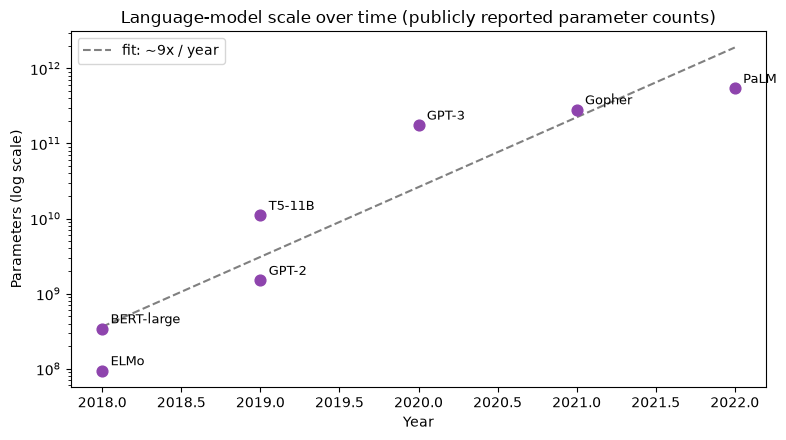

In [1]:
# Plot the scaling trend from publicly reported model sizes, and COMPUTE the growth
# rate from the data (rather than asserting it).
import numpy as np
import matplotlib.pyplot as plt

# ── Landmark language models: (name, year, parameters) — publicly reported counts ──
models = [
    ("ELMo",       2018, 9.4e7),
    ("BERT-large", 2018, 3.4e8),
    ("GPT-2",      2019, 1.5e9),
    ("T5-11B",     2019, 1.1e10),
    ("GPT-3",      2020, 1.75e11),
    ("Gopher",     2021, 2.8e11),
    ("PaLM",       2022, 5.4e11),
]
names  = [m[0] for m in models]
years  = np.array([m[1] for m in models], dtype=float)
params = np.array([m[2] for m in models])

# ── Fit exponential growth: straight line in log-space ────────────────────
slope, intercept = np.polyfit(years, np.log10(params), 1)
growth_per_year = 10 ** slope
print(f"Fitted growth rate: ~{growth_per_year:.0f}x parameters per year (2018-2022 landmarks)")
print("(Note: newer frontier models often do not disclose parameter counts,")
print(" and research focus has partly shifted from raw size to data quality + efficiency.)")

# ── Plot on a log scale with the fitted trend line ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(years, params, s=60, color='#8e44ad', zorder=3)
for x, y, n in zip(years, params, names):
    ax.annotate(n, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=9)
xs = np.linspace(years.min(), years.max(), 100)
ax.plot(xs, 10 ** (slope * xs + intercept), '--', color='gray',
        label=f'fit: ~{growth_per_year:.0f}x / year')
ax.set_yscale('log')
ax.set_xlabel("Year"); ax.set_ylabel("Parameters (log scale)")
ax.set_title("Language-model scale over time (publicly reported parameter counts)")
ax.legend(); plt.tight_layout(); plt.show()

## 🌍 Worked Example — the Mechanism Every Trend Builds On

All the tools in the table above — chatbots, coding agents, multimodal models — share one core
mechanism: **autoregressive next-token prediction**. To connect trends back to fundamentals, we
train a character-level language model (the same mechanism at ~1/1,000,000th of production scale):

- GitHub Copilot generates code token by token this way
- ChatGPT predicts each next token from all previous context
- The scaling trend you just plotted is *this exact model class*, grown by ~9 orders of magnitude

In [2]:
# Train a tiny character-level LSTM language model and generate text from it.
# WHY: this is the same autoregressive mechanism behind every model in the trends table,
# small enough to train in seconds on a CPU.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# ── Vocabulary: map each character to an integer id ───────────────────────
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]


# ── Dataset: every 20-char window predicts the next character ─────────────
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# ── Training: 200 quick steps, a fresh random 256-window batch each time ──
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nSame autoregressive mechanism as ChatGPT — one token at a time,")
print("just ~6 orders of magnitude smaller, hence the garbled output.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or noteu a shear ageos fort an ere tho tis a noumufrand tousle on more and mot osak ar wats afes ir tha cl

Same autoregressive mechanism as ChatGPT — one token at a time,
just ~6 orders of magnitude smaller, hence the garbled output.


## 💬 Discuss

1. Our fit says **~9× parameters per year across 2018–2022**, and Chinchilla says those same models were undertrained. Is the fitted line *wrong*, or is it right about the wrong quantity? What would you have plotted instead if you had known?
2. Frontier labs largely stopped disclosing parameter counts after 2022 — the printed note says so. What does that do to this plot, and what measurable quantity would you fit instead to brief a client in 2026?
3. The toy LSTM below reaches a loss of **0.011** on a short passage and still emits garbage. What does that tell you about using training loss as evidence for any claim about the trend you just plotted?


## ⚠️ Where this breaks

**Extrapolating a four-point trend is not forecasting.** The plot ends in 2022 precisely because the reported quantity stopped being published — and a trend line that cannot be updated cannot be validated, only believed.

**Parameter count is not capability.** Chinchilla-optimal data scaling, data quality, instruction tuning, and inference-time compute all move capability without moving the plotted axis. Since DeepSeek-R1 (arXiv 2501.12948) it has been routine to buy reasoning at inference time instead of at training time — a capability gain that this chart would record as flat.

**The toy model's loss of 0.011 is memorisation, not learning.** A short repeated corpus can be driven to near-zero loss in seconds. Any argument about scaling built on training loss is really an argument about how repetitive the text was — example 06 of Unit 2 measures exactly that.

**Trend lists age badly, including this one.** The five directions in the table are a reasonable 2026 map. Treat the specific tool names as perishable and the *mechanism* — next-token prediction, everywhere — as the durable part.


## 📝 Summary

In this notebook, you:

- Surveyed the five research directions shaping generative AI — **scaling, multimodality,
  alignment, efficiency, and agents** — and the open problems behind them (hallucination,
  reasoning, evaluation)
- **Computed the scaling trend** from publicly reported model sizes (~an order-of-magnitude
  parameter growth per year across 2018–2022 landmark models)
- Trained a toy autoregressive character model to connect every trend back to the shared
  mechanism: next-token prediction

## 📚 References & Further Reading

**Papers:**
- Radford et al. (2019) — [GPT-2: Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- Brown et al. (2020) — [GPT-3](https://arxiv.org/abs/2005.14165)
- Bommasani et al. (2021) — [On the Opportunities and Risks of Foundation Models](https://arxiv.org/abs/2108.07258) *(the survey that named the "foundation model" era)*

**Interactive:**
- [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT) — build GPT in 300 lines
- [The Unreasonable Effectiveness of RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

**State-of-the-Art:** GPT-4, Claude 3.5, Gemini 1.5 — all trained on trillions of tokens with transformer decoders.